In [26]:
#1.Importing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_curve, roc_auc_score


In [27]:
#Load the dataset
df = pd.read_csv("diabetes.csv")
#Displays first five rows
print("First 5 rows:")
print(df.head())
#Information about the dataset used
print("\nDataset Info:")
print(df.info())


First 5 rows:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   

In [28]:
#Define Binary Target
X = df.drop("Outcome", axis=1)
y = df["Outcome"]
print("\nTarget Distribution:")
print(y.value_counts())


Target Distribution:
Outcome
0    500
1    268
Name: count, dtype: int64


In [29]:
#Handle Missing Values (0 → NaN → Median)
cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

# Count zero values
print("Zero values before replacing:")
for col in cols:
    print(col, ":", (df[col] == 0).sum())

# Replace 0 with NaN
df[cols] = df[cols].replace(0, np.nan)

print("\nMissing values after replacing 0 with NaN:")
print(df.isnull().sum())

# Fill NaN with median
df[cols] = df[cols].fillna(df[cols].median())

print("\nMissing values after filling:")
print(df.isnull().sum())



Zero values before replacing:
Glucose : 5
BloodPressure : 35
SkinThickness : 227
Insulin : 374
BMI : 11

Missing values after replacing 0 with NaN:
Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

Missing values after filling:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [30]:
#Feature Scaling
X = df.drop("Outcome", axis=1)
y = df["Outcome"]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [31]:
#Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])


Training samples: 614
Testing samples: 154


In [32]:
#Model Training
model = LogisticRegression(max_iter=1000,random_state=42)
model.fit(X_train, y_train)
print("Model trained successfully.")


Model trained successfully.


In [33]:
#Predictions
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]


In [34]:
#Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)
tn, fp, fn, tp = cm.ravel()
print("\nTrue Negatives:", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives:", tp)


Confusion Matrix:
 [[82 17]
 [21 34]]

True Negatives: 82
False Positives: 17
False Negatives: 21
True Positives: 34


In [35]:
#Accuracy,Precision,Recall,F1 Score
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
print("\nAccuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)



Accuracy: 0.7532467532467533
Precision: 0.6666666666666666
Recall: 0.6181818181818182
F1 Score: 0.6415094339622641


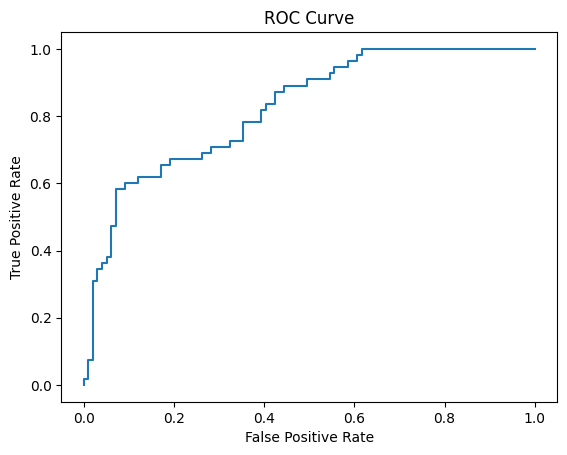

AUC Score: 0.8229568411386594


In [36]:
#ROC Curve+AUC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)
plt.figure()
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()
print("AUC Score:", auc)


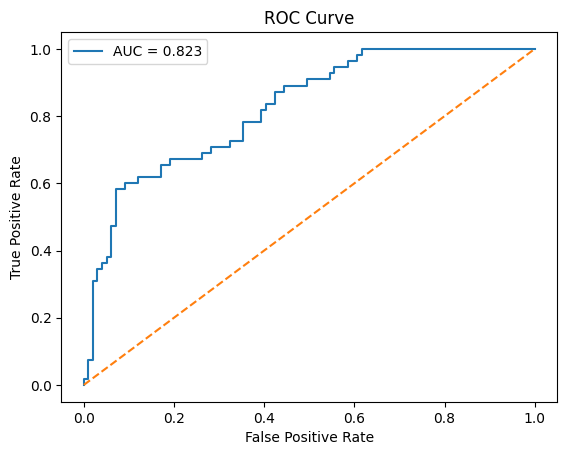

In [37]:
plt.figure()
plt.plot(fpr, tpr, label="AUC = %.3f" % auc)
plt.plot([0,1], [0,1], linestyle='--')  # random line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


In [38]:
#Feature Influence
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0],
    "Odds_Ratio": np.exp(model.coef_[0])
})
coefficients["Abs_Coefficient"] = np.abs(coefficients["Coefficient"])
top5 = coefficients.sort_values(by="Abs_Coefficient", ascending=False).head(5)
print("\nTop 5 Influential Features:")
print(top5[["Feature", "Coefficient", "Odds_Ratio"]])



Top 5 Influential Features:
                    Feature  Coefficient  Odds_Ratio
1                   Glucose     1.114496    3.048033
5                       BMI     0.683509    1.980817
7                       Age     0.401210    1.493632
0               Pregnancies     0.226785    1.254560
6  DiabetesPedigreeFunction     0.200471    1.221978


In [39]:
#Threshold Comparison
threshold = 0.4
y_pred_tuned = (y_prob >= threshold).astype(int)
cm_tuned = confusion_matrix(y_test, y_pred_tuned)
accuracy_tuned = accuracy_score(y_test, y_pred_tuned)
precision_tuned = precision_score(y_test, y_pred_tuned)
recall_tuned = recall_score(y_test, y_pred_tuned)
f1_tuned = f1_score(y_test, y_pred_tuned)
print("\nThreshold 0.4 Results--")
print("Confusion Matrix:\n", cm_tuned)
print("Accuracy:", accuracy_tuned)
print("Precision:", precision_tuned)
print("Recall:", recall_tuned)
print("F1 Score:", f1_tuned)



Threshold 0.4 Results--
Confusion Matrix:
 [[73 26]
 [17 38]]
Accuracy: 0.7207792207792207
Precision: 0.59375
Recall: 0.6909090909090909
F1 Score: 0.6386554621848739


# New section